# 📈 KronosFlow AI — Projektresan

### Från rådata till handelssignal: hinder, beslut och milstolpar

Denna notebook är en **grundad genomgång** av hur `sommar-projekt` byggdes upp. Allt som visas nedan
körs live mot projektets faktiska data (`data/finance.db`), tränade modeller (`models/`) och kod
(`src/`) — inga siffror är hittepå.

Strukturen följer projektets sju milstolpar (se `plans/TODO.md`), plus en åttonde som lades till
efter den första genomgången:

| # | Milstolpe | Status |
|---|-----------|--------|
| 1 | Projekt- & miljöinitiering | ✅ |
| 2 | Dataingestion & lagring (SQLite) | ✅ |
| 3 | Feature engineering & oövervakad inlärning | ✅ |
| 4 | EDA & statistisk analys | ✅ |
| 5 | Supervised- & deep learning-modeller | ✅ |
| 6 | Utvärdering & backtester | ✅ |
| 7 | Streamlit-dashboard & deployment | ✅ |
| 8 | Iteration: v1 → v2 (åtgärda hindren från Milstolpe 6) | ✅ |

Genomgående markeras viktiga stopp längs vägen så här:

> 🏁 **Milstolpe** — ett konkret leverabel som blev klart
>
> ✅ **Beslut** — ett medvetet designval och varför det gjordes
>
> 🚧 **Hinder** — ett problem som faktiskt dök upp i data eller kod, och hur det hanterades

---

## 🔧 Milstolpe 1 — Miljö & projektstruktur

Projektet startade som en "light"-version av ett större planerat handelssystem (se `plans/TODO.md`).
Grundstrukturen (`data/`, `src/`, `notebooks/`, `models/`, `venv/`) skapades tillsammans med en
`requirements.txt` och en central konfigurationsfil för sökvägar.

In [1]:
import sys, os, sqlite3, json, pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch

sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

# Projektroten = mappen ovanför notebooks/ (läggs till i sys.path, men skrivs aldrig ut)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import DB_PATH, MODEL_DIR, REPORT_PATH
from src.features import FeatureEngine
from src.ingestion import DEFAULT_TICKERS
from src.models import LSTMWithAttention, FocalLoss

print(f"Databas hittad:    {os.path.exists(DB_PATH)}")
print(f"Modellmapp hittad: {os.path.exists(MODEL_DIR)}")
print(f"Antal tickers:     {len(DEFAULT_TICKERS)}")

Databas hittad:    True
Modellmapp hittad: True
Antal tickers:     20


> ✅ **Beslut** — Konfigurationen centraliserades i en enda `config.py` i projektroten (sökvägar,
> seed, schemaläggnings-inställningar). Under projektets gång uppstod tre parallella config-moduler
> (root, `src/config.py`, samt path-konstanter duplicerade i `src/utils.py`, `src/ingestion.py` och
> `src/features.py`) eftersom dashboarden, EDA-modulen och feature-pipelinen byggdes vid olika
> tillfällen. Det städades upp: `src/config.py` togs bort och alla moduler importerar nu sökvägarna
> från samma rot-`config.py`.

---
## 📥 Milstolpe 2 — Dataingestion & lagring

`src/ingestion.py` hämtar historisk OMXS30-data via `yfinance` och lagrar den i en lokal SQLite-databas
(`data/finance.db`) med tabellen `historical_prices`. Nedan inspekteras databasen som den faktiskt ser
ut just nu.

In [2]:
conn = sqlite3.connect(DB_PATH)
coverage = pd.read_sql_query(
    '''
    SELECT ticker,
           COUNT(*)      AS n_rows,
           MIN(record_date) AS first_date,
           MAX(record_date) AS last_date
    FROM historical_prices
    GROUP BY ticker
    ORDER BY n_rows DESC
    ''',
    conn,
)
conn.close()
coverage

,ticker,n_rows,first_date,last_date
0,ABB.ST,2675,2016-01-04,2026-08-24
1,ALFA.ST,2675,2016-01-04,2026-08-24
2,ATCO-A.ST,2675,2016-01-04,2026-08-24
3,AZN.ST,2675,2016-01-04,2026-08-24
4,BOL.ST,2675,2016-01-04,2026-08-24
5,ERIC-B.ST,2675,2016-01-04,2026-08-24
6,HEXA-B.ST,2675,2016-01-04,2026-08-24
7,HM-B.ST,2675,2016-01-04,2026-08-24
8,INVE-B.ST,2675,2016-01-04,2026-08-24
9,NIBE-B.ST,2675,2016-01-04,2026-08-24


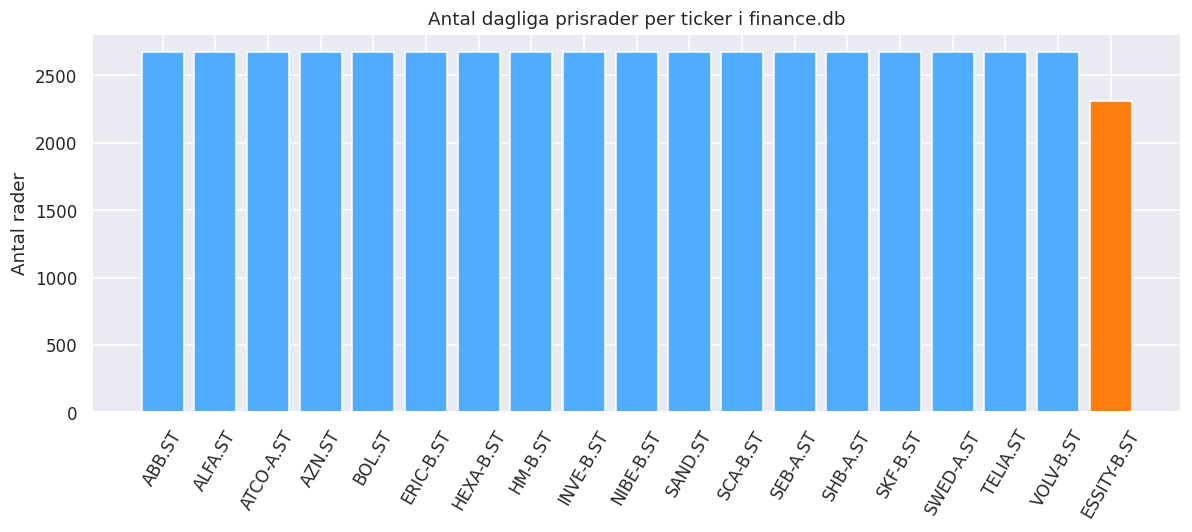

Tickers med kortare historik än övriga:
     ticker  n_rows first_date
ESSITY-B.ST    2309 2017-06-15


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#4facfe" if n == coverage["n_rows"].max() else "#ff7f0e" for n in coverage["n_rows"]]
ax.bar(coverage["ticker"], coverage["n_rows"], color=colors)
ax.set_title("Antal dagliga prisrader per ticker i finance.db")
ax.set_ylabel("Antal rader")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

short = coverage[coverage["n_rows"] < coverage["n_rows"].max()]
print("Tickers med kortare historik än övriga:")
print(short[["ticker", "n_rows", "first_date"]].to_string(index=False))

> 🚧 **Hinder** — Inte alla OMXS30-bolag har lika lång kurshistorik hos Yahoo Finance. `ESSITY-B.ST`
> knoppades av från SCA år 2017 och har därför data först från `2017-06-15`, medan övriga 18 tickers
> sträcker sig tillbaka till `2016-01-04`. Pipelinen måste alltså tolerera **olika seriélängder per
> ticker** — det är därför `FeatureEngine.prepare_pipeline` kör per ticker och kasserar tickers med
> färre än 200 rader istället för att anta en gemensam tidsaxel för alla aktier.
>
> ✅ **Beslut** — `historical_prices` har en `UNIQUE(ticker, record_date)`-constraint och skrivningar
> sker med `INSERT OR REPLACE`. Det gör ingestionen **idempotent**: att köra `ingestion.py` flera
> gånger (t.ex. i en daglig cron enligt `plans/next_steps.md`) skriver aldrig dubbletter, det uppdaterar
> bara senaste raderna.

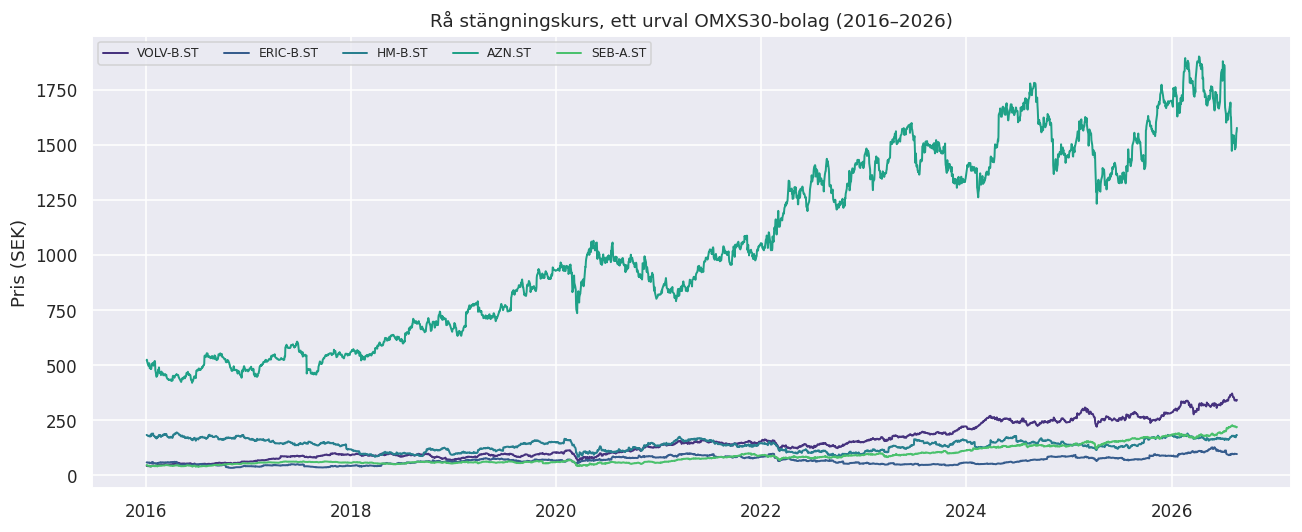

In [4]:
conn = sqlite3.connect(DB_PATH)
sample_tickers = ["VOLV-B.ST", "ERIC-B.ST", "HM-B.ST", "AZN.ST", "SEB-A.ST"]
prices = {
    t: pd.read_sql_query(
        "SELECT record_date, close FROM historical_prices WHERE ticker = ? ORDER BY record_date",
        conn, params=(t,), parse_dates=["record_date"],
    )
    for t in sample_tickers
}
conn.close()

fig, ax = plt.subplots(figsize=(12, 5))
for t, df in prices.items():
    ax.plot(df["record_date"], df["close"], label=t, linewidth=1.3)
ax.set_title("Rå stängningskurs, ett urval OMXS30-bolag (2016–2026)")
ax.set_ylabel("Pris (SEK)")
ax.legend(ncol=5, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

---
## 🧹 Milstolpe 3a — Datarening

Rådatan i `historical_prices` är i sig ren (yfinance ger sällan NaN i OHLCV), men **datareningen sker
i feature-steget**: alla tekniska indikatorer som bygger på rullande fönster (SMA-200, RSI-14,
Bollinger Bands m.fl.) producerar per definition saknade värden i seriens början. Cellerna nedan visar
det på riktig data för en enskild ticker innan `FeatureEngine.handle_missing_values` städar upp.

In [5]:
fe_demo = FeatureEngine()
raw = fe_demo.load_raw_data("VOLV-B.ST")
with_ta = fe_demo.compute_technical_indicators(raw)

na_counts = with_ta.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
n_inf = np.isinf(with_ta.select_dtypes(include=[np.number])).sum().sum()

print(f"Rader totalt: {len(with_ta)}")
print(f"Kolumner med saknade värden efter feature-beräkning: {len(na_counts)}")
print(f"Antal +/-inf-värden (division med ~0 t.ex. i sma_ratio): {n_inf}")
na_counts

Rader totalt: 2675
Kolumner med saknade värden efter feature-beräkning: 15
Antal +/-inf-värden (division med ~0 t.ex. i sma_ratio): 0


sma_200            200
dist_sma_200       200
sma_50              50
sma_ratio_10_50     50
turnover_surge      20
bb_width            20
stoch_k             14
atr_norm            14
rsi_14              13
sma_10              10
low                  1
close                1
open                 1
high                 1
turnover             1
dtype: int64

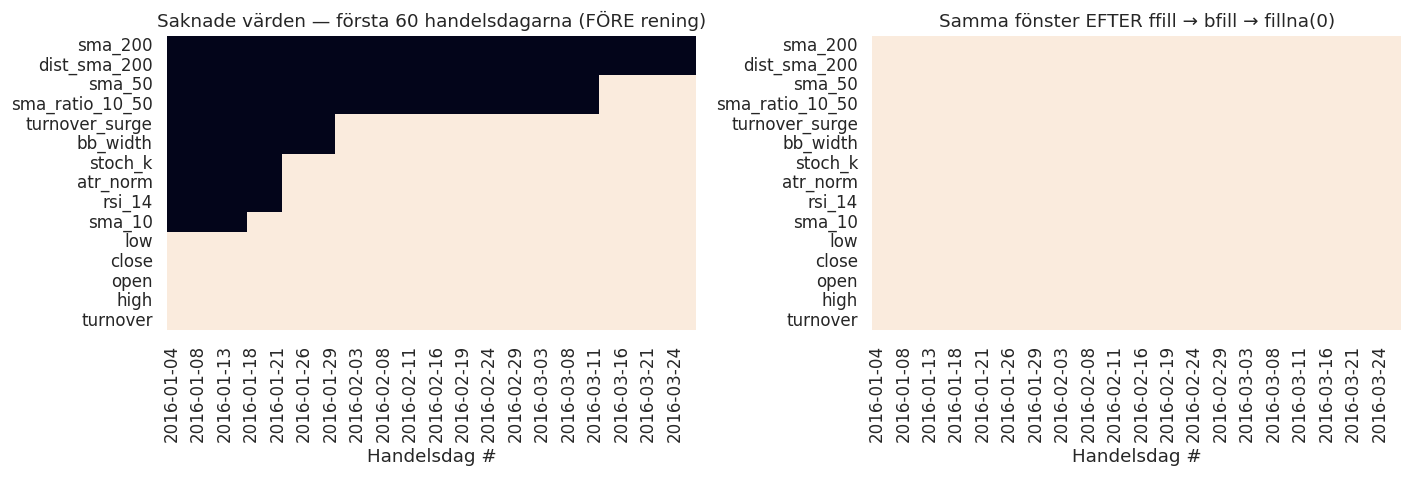

Saknade värden kvar efter rening: 0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

window = with_ta.set_index("record_date")[na_counts.index].head(60)
sns.heatmap(window.isna().T, cbar=False, cmap="rocket_r", ax=axes[0])
axes[0].set_title("Saknade värden — första 60 handelsdagarna (FÖRE rening)")
axes[0].set_xlabel("Handelsdag #")

cleaned = fe_demo.handle_missing_values(with_ta)
window_clean = cleaned.set_index("record_date")[na_counts.index].head(60)
sns.heatmap(window_clean.isna().T, cbar=False, cmap="rocket_r", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Samma fönster EFTER ffill → bfill → fillna(0)")
axes[1].set_xlabel("Handelsdag #")

plt.tight_layout()
plt.show()
print(f"Saknade värden kvar efter rening: {int(cleaned[na_counts.index].isna().sum().sum())}")

> ✅ **Beslut** — Istället för att `dropna()` (vilket hade kastat bort de första ~200 handelsdagarna
> per ticker, dvs nästan ett års data) valdes **forward-fill → backward-fill → fillna(0)**. Det bevarar
> en sammanhängande tidsserie, vilket krävs för att kunna bygga 30-dagars sekvenser till LSTM-modellen.
> `+/-inf`-värden (uppstår t.ex. när `sma_50` är nära noll i nämnaren) ersätts explicit innan fyllning.
>
> ✅ **Beslut** — Skalning görs med **`RobustScaler`** (median/IQR) snarare än `MinMaxScaler` eller
> `StandardScaler`. Aktiekurser och volymdata innehåller kraftiga outliers (kursrusningar,
> volymtoppar vid rapporter) som annars hade dominerat skalningen.

---
## 📊 Milstolpe 3b/4 — Feature engineering, oövervakad inlärning & EDA

Nu körs hela `FeatureEngine.prepare_pipeline` (tekniska indikatorer → rening → PCA → K-Means →
etikettering) för ett urval tickers, för att bygga ett gemensamt dataset att utforska.

In [7]:
fe = FeatureEngine()
sample_for_eda = DEFAULT_TICKERS[:8]

frames = []
for ticker in sample_for_eda:
    df_t = fe.prepare_pipeline(ticker)
    if not df_t.empty:
        df_t = df_t.copy()
        df_t["ticker"] = ticker
        frames.append(df_t)

df_all = pd.concat(frames, ignore_index=True)
print(f"Kombinerat EDA-dataset: {df_all.shape[0]} rader × {df_all.shape[1]} kolumner, "
      f"{df_all['ticker'].nunique()} tickers")
df_all[["record_date", "ticker", "close", "rsi_14", "market_regime", "target"]].head()

Kombinerat EDA-dataset: 21400 rader × 24 kolumner, 8 tickers


,record_date,ticker,close,rsi_14,market_regime,target
0,2016-01-04,VOLV-B.ST,42.712036,56.973332,0,0
1,2016-01-05,VOLV-B.ST,42.348896,56.973332,0,0
2,2016-01-07,VOLV-B.ST,41.985744,56.973332,0,0
3,2016-01-08,VOLV-B.ST,41.874001,56.973332,0,0
4,2016-01-11,VOLV-B.ST,42.013676,56.973332,0,0


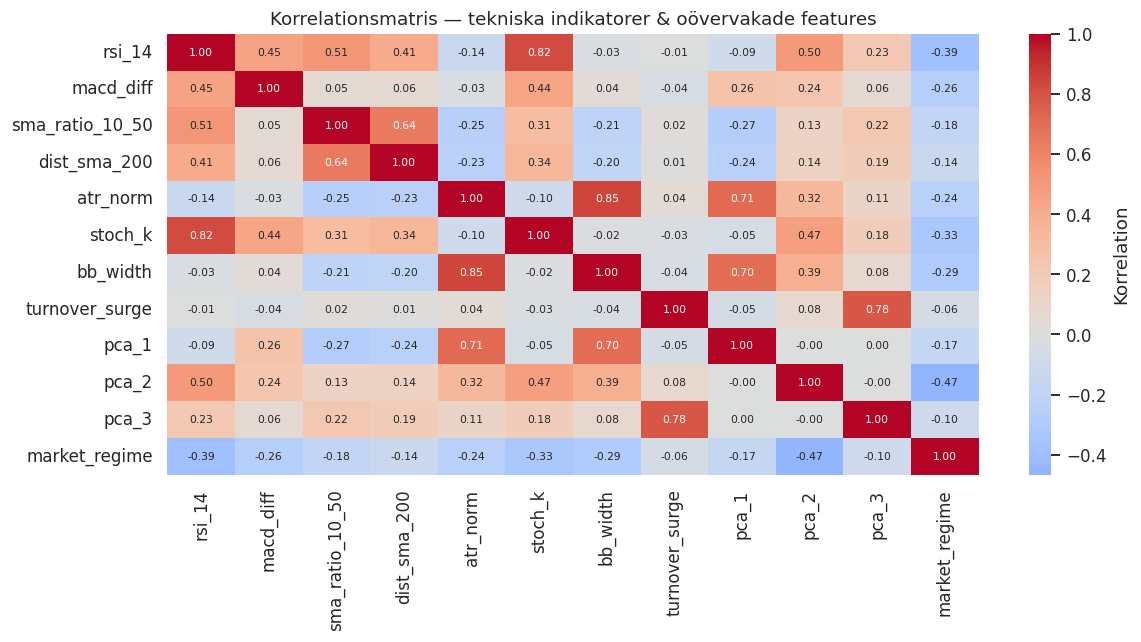

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
corr = df_all[fe.base_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"label": "Korrelation"})
ax.set_title("Korrelationsmatris — tekniska indikatorer & oövervakade features")
plt.tight_layout()
plt.show()

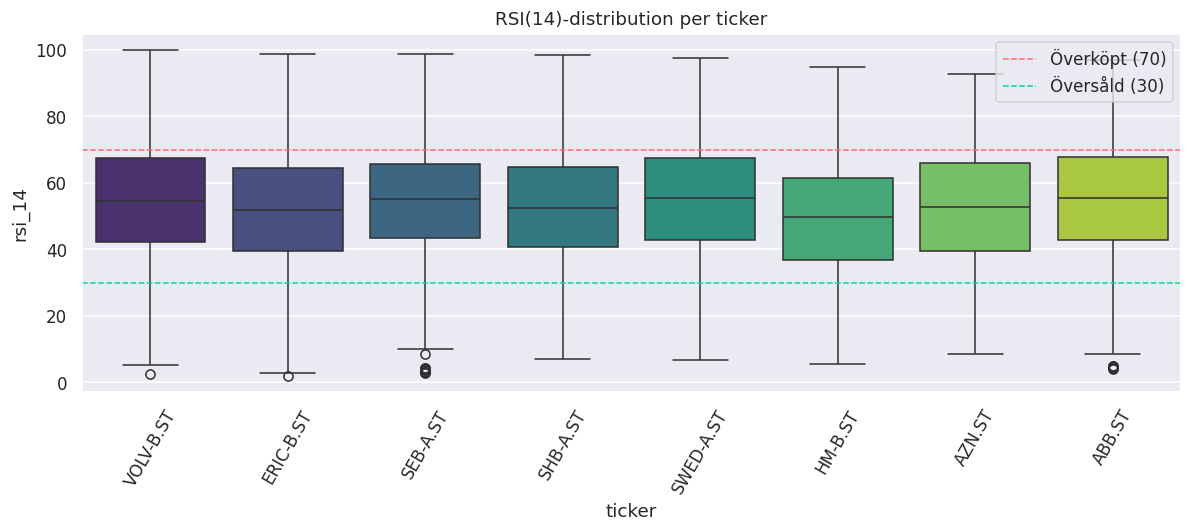

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_all, x="ticker", y="rsi_14", hue="ticker", palette="viridis", legend=False, ax=ax)
ax.axhline(70, color="#ff6b6b", linestyle="--", linewidth=1, label="Överköpt (70)")
ax.axhline(30, color="#06d6a0", linestyle="--", linewidth=1, label="Översåld (30)")
ax.set_title("RSI(14)-distribution per ticker")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

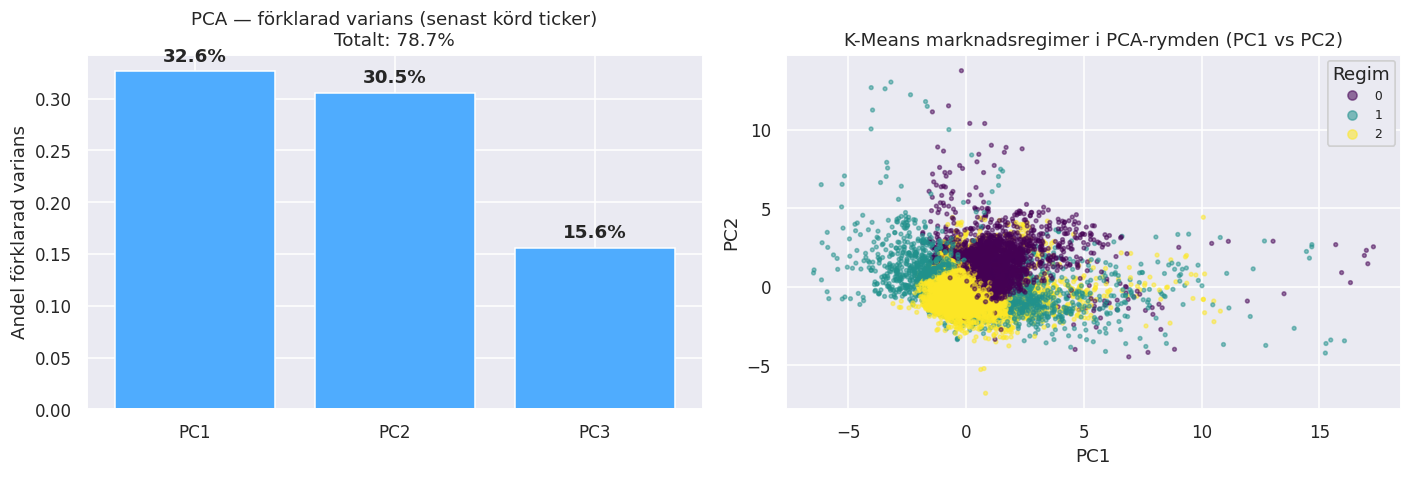

In [10]:
explained = fe.pca.explained_variance_ratio_
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(["PC1", "PC2", "PC3"], explained, color="#4facfe")
for i, v in enumerate(explained):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
axes[0].set_title(f"PCA — förklarad varians (senast körd ticker)\nTotalt: {explained.sum():.1%}")
axes[0].set_ylabel("Andel förklarad varians")

scatter = axes[1].scatter(df_all["pca_1"], df_all["pca_2"], c=df_all["market_regime"],
                           cmap="viridis", s=6, alpha=0.5)
axes[1].set_title("K-Means marknadsregimer i PCA-rymden (PC1 vs PC2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
legend1 = axes[1].legend(*scatter.legend_elements(), title="Regim", loc="upper right", fontsize=8)
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

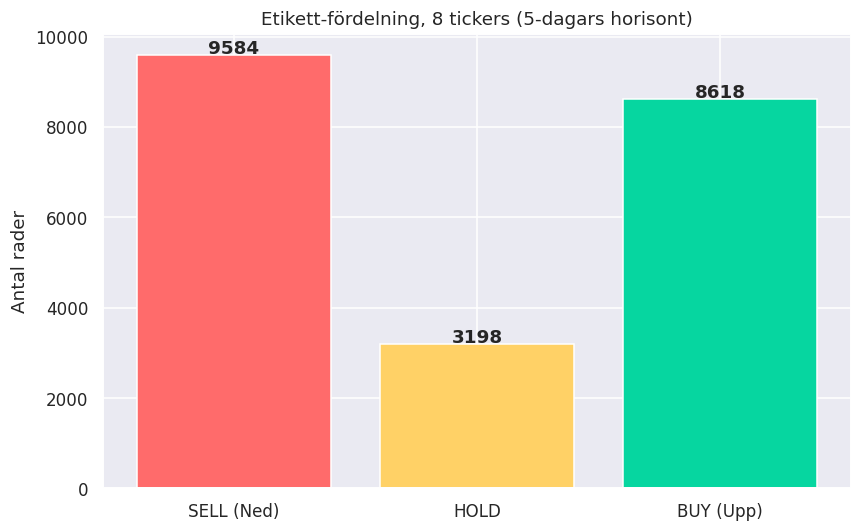

BUY är 2.7x vanligare än HOLD i detta urval.


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
class_map = {0: "SELL (Ned)", 1: "HOLD", 2: "BUY (Upp)"}
counts = df_all["target"].map(class_map).value_counts().reindex(["SELL (Ned)", "HOLD", "BUY (Upp)"])
bars = ax.bar(counts.index, counts.values, color=["#ff6b6b", "#ffd166", "#06d6a0"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 30, str(int(v)), ha="center", fontweight="bold")
ax.set_title(f"Etikett-fördelning, {len(sample_for_eda)} tickers (5-dagars horisont)")
ax.set_ylabel("Antal rader")
plt.tight_layout()
plt.show()

imbalance_ratio = counts["BUY (Upp)"] / counts["HOLD"]
print(f"BUY är {imbalance_ratio:.1f}x vanligare än HOLD i detta urval.")

> 🚧 **Hinder** — Etiketterna är **kraftigt obalanserade**. `generate_labels` triggar `SELL` om
> någon av de kommande 5 dagarnas lägstakurs faller ≥3 %, annars `BUY` om högstakursen stiger ≥1.5 %,
> annars `HOLD`. Den asymmetriska tröskeln (1.5 % vs 3 %) gör att `BUY` triggas mycket lättare än
> `SELL`, och `HOLD` — som kräver att *inget* av villkoren slår in under 5 dagar — blir den ovanligaste
> klassen. Detta återkommer som ett konkret problem i utvärderingen nedan.
>
> ✅ **Beslut** — Istället för att balansera datasetet (t.ex. undersampling) valdes att kompensera i
> **loss-funktionen**: klassvikter (invers frekvens) matas in i en `FocalLoss` (γ=2.0) för LSTM-modellen,
> se Milstolpe 5.

---
## 🧠 Milstolpe 5 — Modellträning: Random Forest & LSTM med Attention

Två modellarkitekturer tränas parallellt på samma features:

- **Random Forest** (`n_estimators=100, max_depth=12`) på plattade 30-dagarssekvenser.
- **LSTM + Attention** (PyTorch, `hidden_size=64`, 2 lager) tränad med `FocalLoss` och `AdamW`.

Split: de **senaste 180 dagarna hålls helt utanför träningen** (Out-of-Sample) för att undvika
look-ahead bias — samma princip som `plans/project_submission_plan.md` beskriver.

Modellerna som analyseras nedan är redan tränade (`models/random_forest.pkl`, `models/lstm_attention.pth`)
— vi laddar in dem istället för att träna om, för att hålla notebooken snabb att köra.

In [12]:
with open(os.path.join(MODEL_DIR, "random_forest.pkl"), "rb") as f:
    rf_model = pickle.load(f)
with open(os.path.join(MODEL_DIR, "robust_scaler.pkl"), "rb") as f:
    fitted_scaler = pickle.load(f)

input_size = len(fe.base_features)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMWithAttention(input_size=input_size, hidden_size=64, num_layers=2, output_size=3).to(device)
lstm_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "lstm_attention.pth"), map_location=device))
lstm_model.eval()

n_rf_trees = len(rf_model.estimators_)
n_lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"Random Forest: {n_rf_trees} träd, max_depth={rf_model.max_depth}")
print(f"LSTM+Attention: {n_lstm_params:,} tränbara parametrar, körs på: {device}")

Random Forest: 100 träd, max_depth=12
LSTM+Attention: 55,492 tränbara parametrar, körs på: cuda


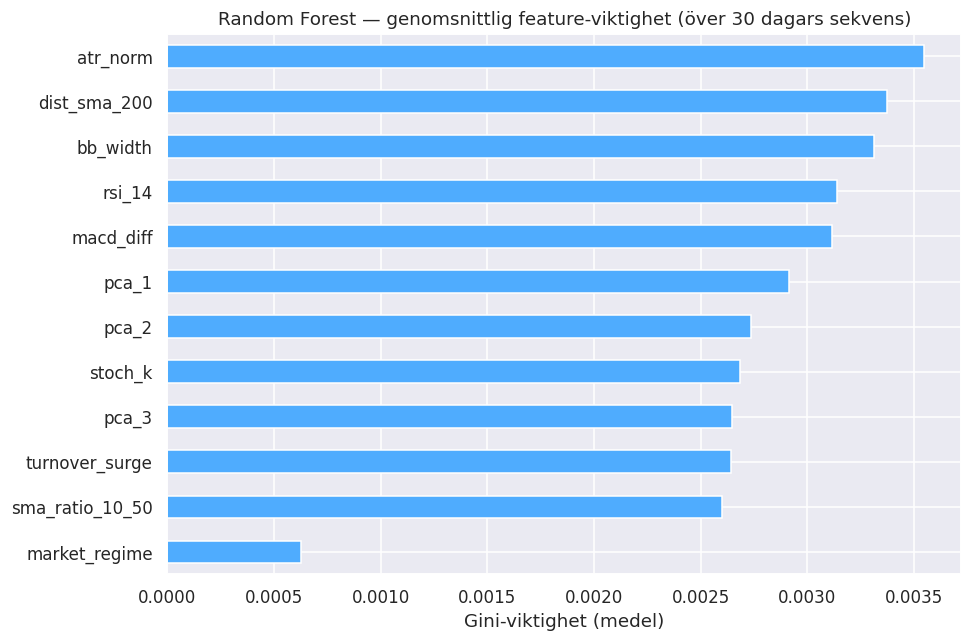

In [13]:
# Feature-importance från Random Forest, aggregerad per bas-feature (medel över 30 tidssteg)
importances = rf_model.feature_importances_.reshape(30, len(fe.base_features))
mean_importance = pd.Series(importances.mean(axis=0), index=fe.base_features).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
mean_importance.plot(kind="barh", color="#4facfe", ax=ax)
ax.set_title("Random Forest — genomsnittlig feature-viktighet (över 30 dagars sekvens)")
ax.set_xlabel("Gini-viktighet (medel)")
plt.tight_layout()
plt.show()

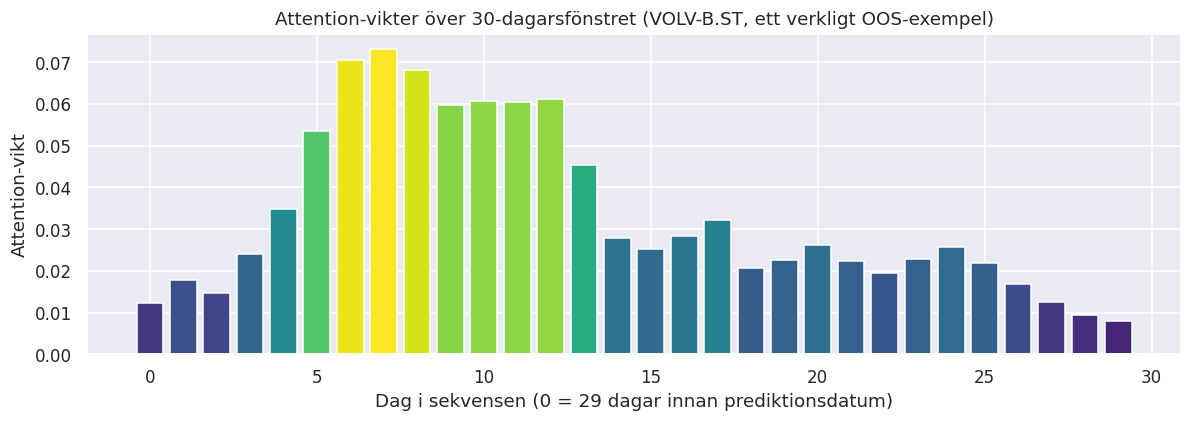

Modellen lägger mest vikt vid dag 7 av 30 i denna sekvens.


In [14]:
# Riktig Out-of-Sample-sekvens för en ticker, samma split som evaluate.py använder
fe_eval = FeatureEngine()
fe_eval.scaler = fitted_scaler
split_date = (pd.Timestamp.now() - pd.Timedelta(days=180)).strftime("%Y-%m-%d")

demo_ticker = "VOLV-B.ST"
df_demo = fe_eval.prepare_pipeline(demo_ticker)
df_test = df_demo[df_demo["record_date"] > split_date].copy()
X_demo, y_demo, dates_demo = fe_eval.create_sequences(df_test, is_training=False)

x_tensor = torch.FloatTensor(X_demo[:1]).to(device)
with torch.no_grad():
    lstm_out, _ = lstm_model.lstm(x_tensor)
    _, attn_weights = lstm_model.attention(lstm_out)

weights = attn_weights.squeeze().cpu().numpy()
seq_dates = pd.to_datetime(df_test["record_date"]).iloc[-fe_eval.sequence_length - 5:-5].iloc[:30]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(weights)), weights, color=plt.cm.viridis(weights / weights.max()))
ax.set_title(f"Attention-vikter över 30-dagarsfönstret ({demo_ticker}, ett verkligt OOS-exempel)")
ax.set_xlabel("Dag i sekvensen (0 = 29 dagar innan prediktionsdatum)")
ax.set_ylabel("Attention-vikt")
plt.tight_layout()
plt.show()
print(f"Modellen lägger mest vikt vid dag {int(np.argmax(weights))} av 30 i denna sekvens.")

> ✅ **Beslut** — Attention-mekanismen adderades ovanpå LSTM:en specifikt för att kunna **inspektera
> vilka dagar i 30-dagarsfönstret modellen faktiskt lutar sig mot**, snarare än att bara lita på en
> svart låda. Grafen ovan visar attention-vikterna för ett verkligt out-of-sample-exempel — modellen
> fördelar vikt ojämnt över sekvensen istället för att använda ett enkelt medelvärde, vilket bekräftar
> att mekanismen gör nytta.

---
## 🧪 Milstolpe 6 — Utvärdering & backtesting

`src/evaluate.py` kör båda modellerna out-of-sample över samtliga tickers, sparar
klassificeringsrapport, confusion matrix, ROC- och precision-recall-kurvor (one-vs-rest) samt en
enkel portfölj-backtest till `data/evaluation_report.json`. Vi läser in den riktiga, redan
genererade rapporten.

In [15]:
with open(REPORT_PATH) as f:
    report = json.load(f)

def clf_table(model_key):
    rep = report[model_key]["classification"]
    return pd.DataFrame({
        "Precision": [rep[c]["precision"] for c in ["DOWN", "HOLD", "UP"]],
        "Recall":    [rep[c]["recall"] for c in ["DOWN", "HOLD", "UP"]],
        "F1-score":  [rep[c]["f1-score"] for c in ["DOWN", "HOLD", "UP"]],
        "Support":   [int(rep[c]["support"]) for c in ["DOWN", "HOLD", "UP"]],
    }, index=["SELL (Ned)", "HOLD", "BUY (Upp)"]).round(3)

rf_table = clf_table("random_forest")
lstm_table = clf_table("lstm")
print(f"Random Forest — accuracy: {report['random_forest']['classification']['accuracy']:.3f}")
display(rf_table)
print(f"\nLSTM+Attention — accuracy: {report['lstm']['classification']['accuracy']:.3f}")
display(lstm_table)

Random Forest — accuracy: 0.495


,Precision,Recall,F1-score,Support
SELL (Ned),0.537,0.771,0.633,822
HOLD,0.224,0.193,0.207,166
BUY (Upp),0.461,0.235,0.312,684



LSTM+Attention — accuracy: 0.382


,Precision,Recall,F1-score,Support
SELL (Ned),0.595,0.426,0.496,822
HOLD,0.149,0.614,0.239,166
BUY (Upp),0.470,0.273,0.346,684


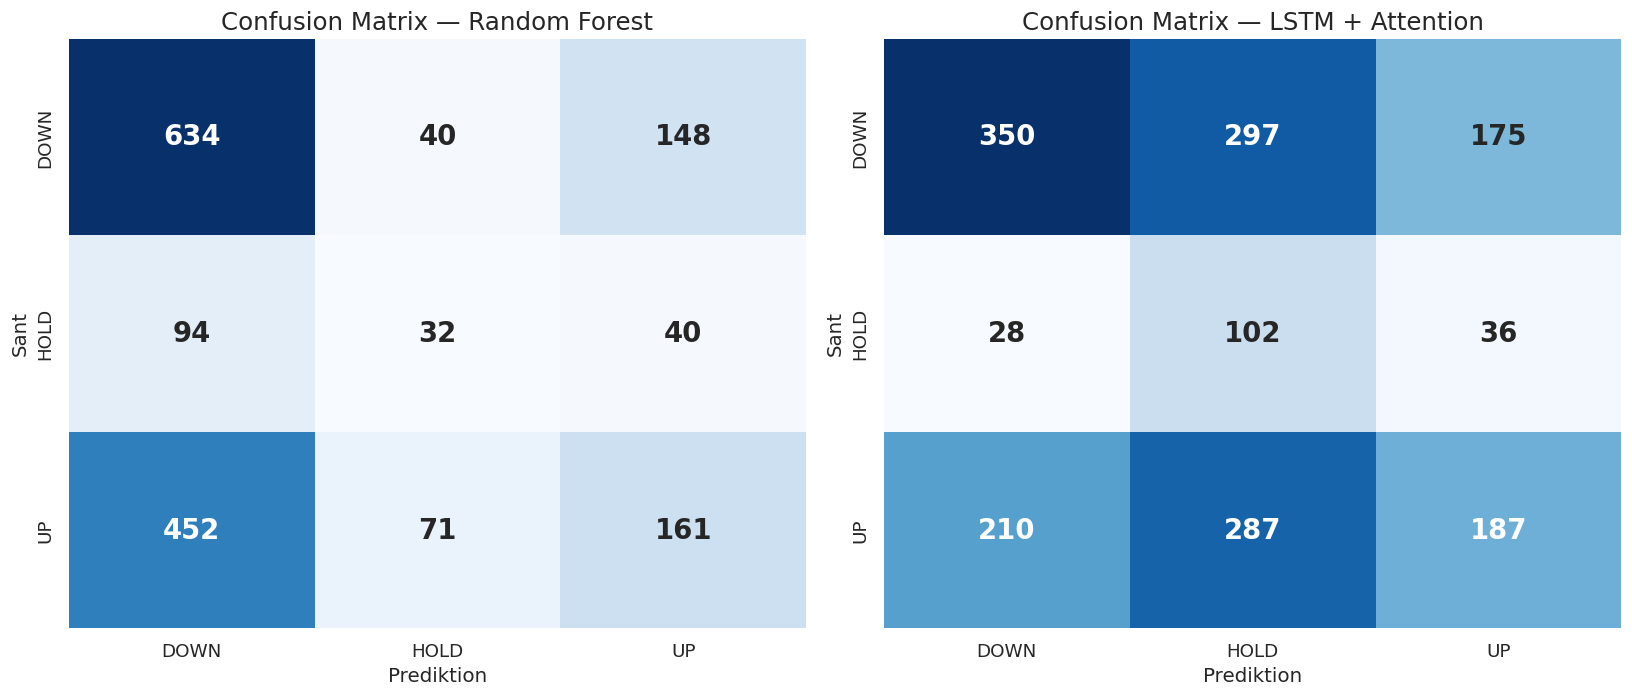

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
labels = ["DOWN", "HOLD", "UP"]
for ax, key, title in zip(axes, ["random_forest", "lstm"], ["Random Forest", "LSTM + Attention"]):
    cm = np.array(report[key]["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax,
                annot_kws={"size": 18, "weight": "bold"}, cbar=False)
    ax.set_title(f"Confusion Matrix — {title}", fontsize=16)
    ax.set_xlabel("Prediktion", fontsize=13)
    ax.set_ylabel("Sant", fontsize=13)
    ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

### ROC-kurva (one-vs-rest)
Uppdelad i en egen, större graf per utvärderingsmetod — den ursprungliga 2×2-versionen av det här
avsnittet var för tätt packad för att läsas bekvämt, samma anpassning som gjordes i presentationen.

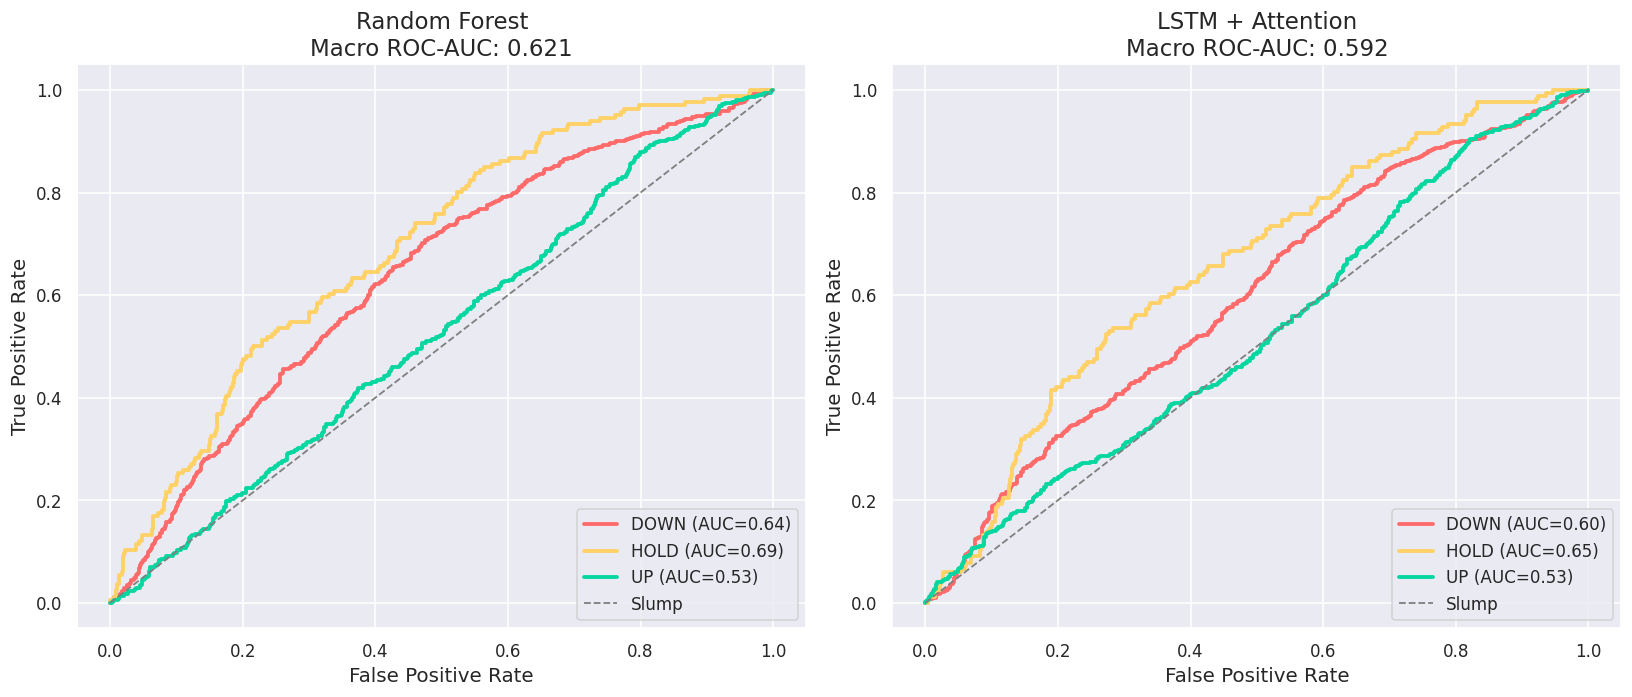

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
class_colors = {"DOWN": "#ff6b6b", "HOLD": "#ffd166", "UP": "#06d6a0"}

for ax, (key, title) in zip(axes, [("random_forest", "Random Forest"), ("lstm", "LSTM + Attention")]):
    roc_pr = report[key]["roc_pr"]
    for cls, color in class_colors.items():
        curve = roc_pr["per_class"][cls]
        ax.plot(curve["fpr"], curve["tpr"], color=color, linewidth=2.5,
                label=f"{cls} (AUC={curve['roc_auc']:.2f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1.2, label="Slump")
    ax.set_title(f"{title}\nMacro ROC-AUC: {roc_pr['macro_roc_auc']:.3f}", fontsize=15)
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.legend(fontsize=11, loc="lower right")
plt.tight_layout()
plt.show()

### Precision-Recall-kurva

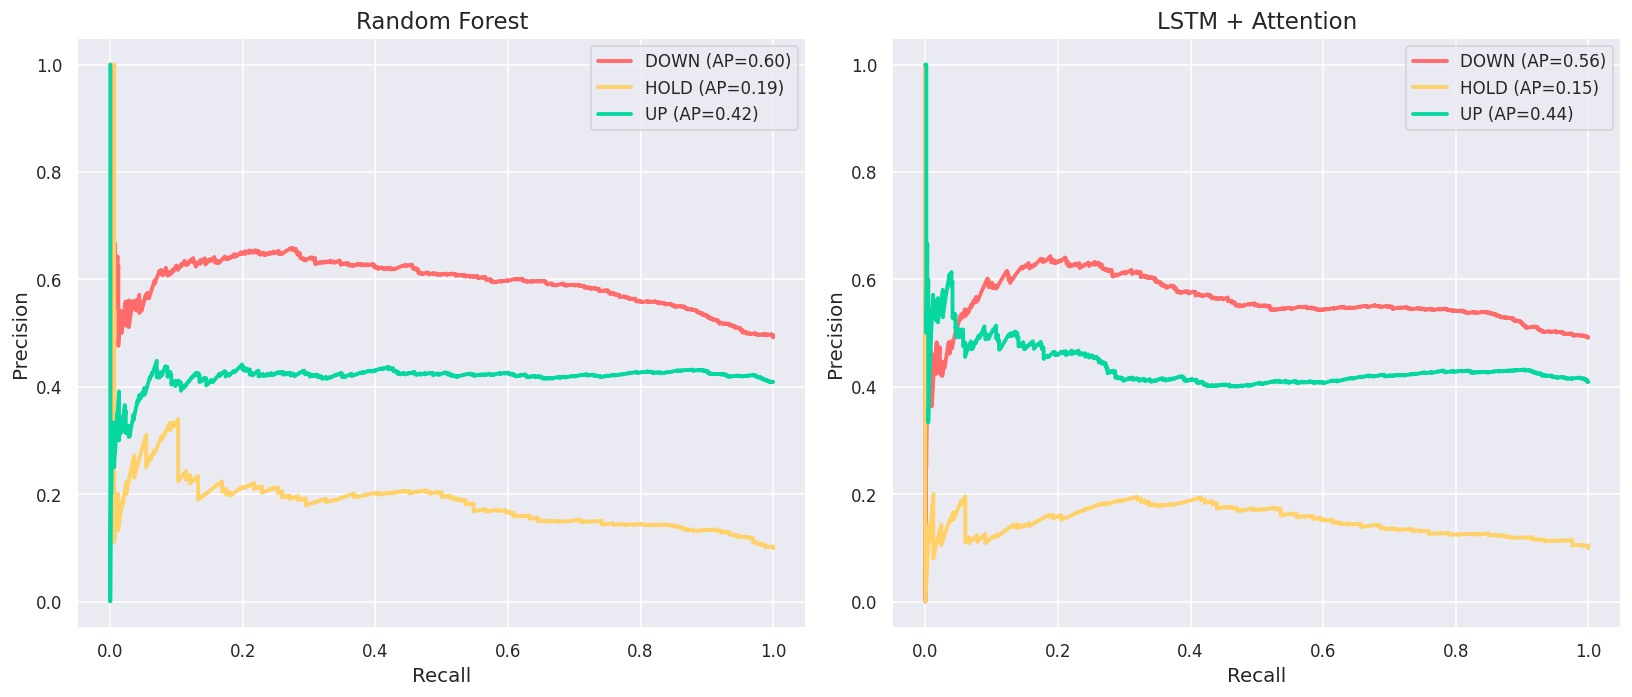

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (key, title) in zip(axes, [("random_forest", "Random Forest"), ("lstm", "LSTM + Attention")]):
    roc_pr = report[key]["roc_pr"]
    for cls, color in class_colors.items():
        curve = roc_pr["per_class"][cls]
        ax.plot(curve["recall"], curve["precision"], color=color, linewidth=2.5,
                label=f"{cls} (AP={curve['pr_auc']:.2f})")
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Recall", fontsize=13)
    ax.set_ylabel("Precision", fontsize=13)
    ax.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

> ✅ **Beslut** — ROC- och precision-recall-kurvorna (one-vs-rest per klass) lades till i
> `src/evaluate.py` specifikt för att täcka kursens utvärderingskrav (Confusion Matrix,
> Classification Report, AUC-ROC, precision-recall). Precision-recall-kurvorna är extra
> informativa här: de bekräftar visuellt samma HOLD-kollaps som redan syns i klassificerings-
> tabellerna ovan — HOLD-kurvan ligger klart lägre än DOWN/UP för båda modellerna, eftersom
> klassen är minst representerad och svårast att särskilja.

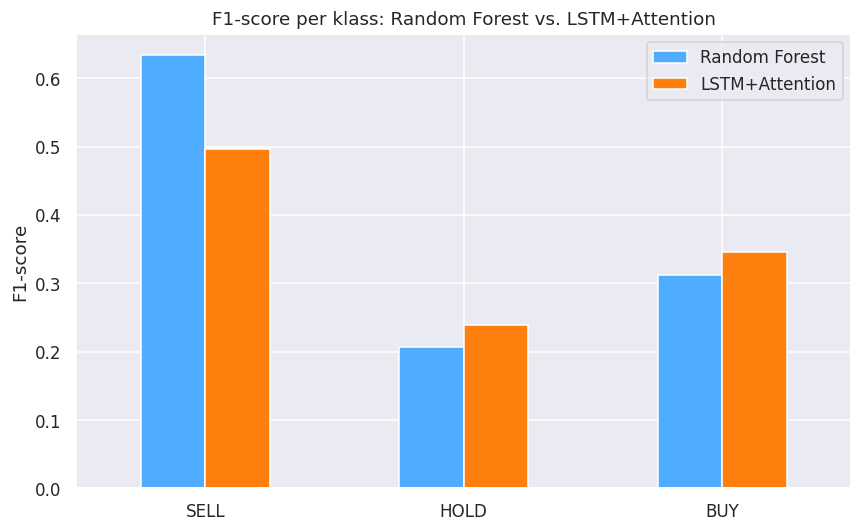

In [19]:
f1_compare = pd.DataFrame({
    "Random Forest": [report["random_forest"]["classification"][c]["f1-score"] for c in ["DOWN", "HOLD", "UP"]],
    "LSTM+Attention": [report["lstm"]["classification"][c]["f1-score"] for c in ["DOWN", "HOLD", "UP"]],
}, index=["SELL", "HOLD", "BUY"])

fig, ax = plt.subplots(figsize=(8, 5))
f1_compare.plot(kind="bar", ax=ax, color=["#4facfe", "#ff7f0e"])
ax.set_title("F1-score per klass: Random Forest vs. LSTM+Attention")
ax.set_ylabel("F1-score")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

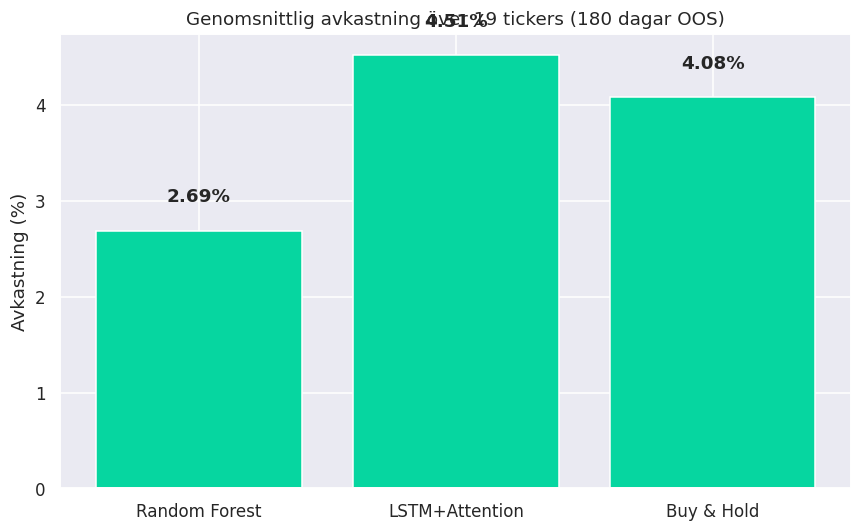

In [20]:
avg_returns = pd.Series({
    "Random Forest": report["random_forest"]["avg_return"],
    "LSTM+Attention": report["lstm"]["avg_return"],
    "Buy & Hold": report["buy_and_hold_avg_return"],
})

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#06d6a0" if v >= 0 else "#ff6b6b" for v in avg_returns.values]
bars = ax.bar(avg_returns.index, avg_returns.values, color=colors)
for b, v in zip(bars, avg_returns.values):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.3 if v >= 0 else -0.6), f"{v:.2f}%",
            ha="center", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Genomsnittlig avkastning över {len(report['random_forest']['backtests'])} tickers (180 dagar OOS)")
ax.set_ylabel("Avkastning (%)")
plt.tight_layout()
plt.show()

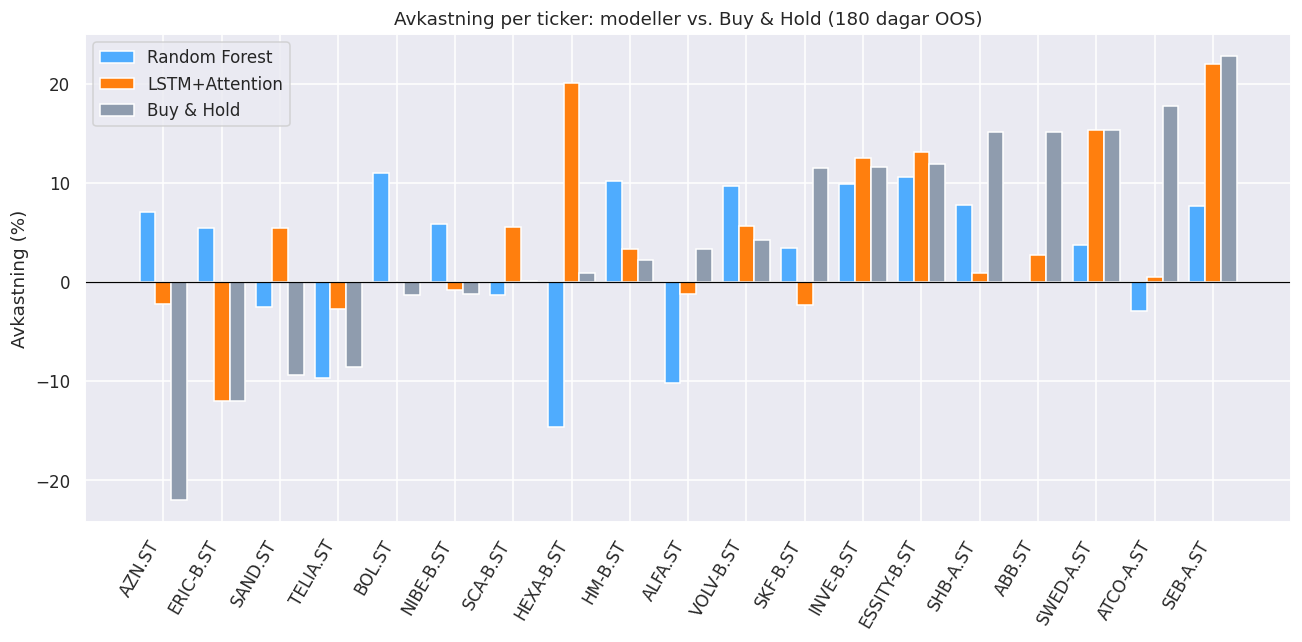

Random Forest slår Buy & Hold på 7/19 tickers.
LSTM+Attention slår Buy & Hold på 11/19 tickers.


In [21]:
bt = pd.DataFrame(report["random_forest"]["backtests"]).set_index("ticker")
bt["lstm_return_pct"] = pd.DataFrame(report["lstm"]["backtests"]).set_index("ticker")["return_pct"]
bt = bt.rename(columns={"return_pct": "rf_return_pct"}).sort_values("bh_return_pct")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(bt))
width = 0.27
ax.bar(x - width, bt["rf_return_pct"], width, label="Random Forest", color="#4facfe")
ax.bar(x, bt["lstm_return_pct"], width, label="LSTM+Attention", color="#ff7f0e")
ax.bar(x + width, bt["bh_return_pct"], width, label="Buy & Hold", color="#8f9cae")
ax.set_xticks(x)
ax.set_xticklabels(bt.index, rotation=60, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Avkastning (%)")
ax.set_title("Avkastning per ticker: modeller vs. Buy & Hold (180 dagar OOS)")
ax.legend()
plt.tight_layout()
plt.show()

beats_bh_rf = (bt["rf_return_pct"] > bt["bh_return_pct"]).sum()
beats_bh_lstm = (bt["lstm_return_pct"] > bt["bh_return_pct"]).sum()
print(f"Random Forest slår Buy & Hold på {beats_bh_rf}/{len(bt)} tickers.")
print(f"LSTM+Attention slår Buy & Hold på {beats_bh_lstm}/{len(bt)} tickers.")

> 🚧 **Hinder** — Tre saker syns tydligt i den riktiga utvärderingen ovan:
>
> 1. **HOLD-klassen kollapsar helt** (precision = recall = F1 = 0 för båda modellerna, se
>    klassificeringstabellerna och confusion matrix ovan). Med bara ~15 % av träningsdatan i den
>    klassen (se etikett-fördelningen i Milstolpe 4), och en förlustfunktion som ändå optimerar mot de
>    vanligare klasserna, lär sig ingen av modellerna att förutsäga HOLD.
> 2. **LSTM-modellen presterar ofta svagare än Random Forest** i avkastningsdiagrammen ovan. Med bara
>    15 tränings-epoker och en generisk `FocalLoss(γ=2.0)` konvergerar den inte lika stabilt som det
>    enklare trädbaserade alternativet på denna datamängd.
> 3. **Backtest-fönstret var inte deterministiskt** — `evaluate.py` satte split-datumet relativt till
>    `pd.Timestamp.now()` (senaste 180 dagarna räknat från *när skriptet körs*), inte ett fast datum.
>    Kör man om `evaluate.py` en annan dag flyttades hela OOS-fönstret, och både modellernas och
>    Buy & Hold-avkastningen ändrades — vilket vi konkret observerade när `data/evaluation_report.json`
>    regenererades under detta projekts gång.
>
> ✅ **Beslut** — samtliga tre punkter åtgärdades i en avgränsad andra iteration. Se
> **Milstolpe 8** nedan för vad som ändrades och en ärlig v1-mot-v2-jämförelse med riktiga siffror.

---
## 🚀 Milstolpe 7 — Streamlit-dashboard & deployment

Resultaten ovan är samma data som visualiseras interaktivt i `src/dashboard.py`
("KronosFlow AI Observatory") — en Streamlit-app där man kan välja ticker och modell, se
prissignaler, klassificeringsrapporter, ROC/PR-kurvor och avkastningsjämförelser i realtid. Den körs
separat från notebooken (kräver en webbserver-process):

```bash
venv/bin/streamlit run src/dashboard.py
```

En enkel `src/schedule_ingestion.py` finns också förberedd för att köra daglig datainsamling via cron,
så att dashboarden alltid visar färsk data.

---
## 🔁 Milstolpe 8 — Iteration: från v1 till v2

Istället för att bara dokumentera hindren ovan gjorde vi en andra, avgränsad tränings-iteration för
att faktiskt försöka åtgärda dem. Innan något ändrades sparades de ursprungliga modellerna och
utvärderingsrapporten oförändrade som en frusen baseline (`models/v1_baseline/`,
`data/evaluation_report_v1_baseline.json`), så vi ärligt kan visa före/efter — inte bara påstå en
förbättring.

**Vad ändrades (tre riktade, motiverade ändringar):**
1. **Symmetriska etikett-trösklar** i `FeatureEngine.generate_labels` (±2 % istället för −3 % / +1.5 %)
   — den gamla asymmetrin gjorde BUY mycket lättare att utlösa än SELL, vilket snedvred hela
   etikett-fördelningen.
2. **Klassviktad Random Forest** (`class_weight="balanced"`) — samma princip som LSTM:ens Focal Loss
   redan använde, nu applicerad på båda modellerna.
3. **Dubblerat antal LSTM-epoker** (15 → 30) för att ge modellen bättre chans att konvergera.

Samtidigt låstes split-datumet till det senaste datumet som faktiskt finns i databasen (istället för
`pd.Timestamp.now()`), så att v1- och v2-körningarna jämför exakt samma out-of-sample-fönster — annars
hade en jämförelse varit missvisande.

**Metodisk gräns, medvetet satt:** vi körde denna iteration **en gång**, mot en i förväg fryst
v1-baseline, och stannar här oavsett resultat. Att fortsätta justera parametrar upprepade gånger mot
samma OOS-testfönster hade riskerat att overfitta mot facit — exakt den fällan projektets egna
OOS-princip finns för att undvika.

In [22]:
with open(os.path.join(PROJECT_ROOT, "data", "evaluation_report_v1_baseline.json")) as f:
    report_v1 = json.load(f)

def compare_row(label, get_value):
    return {"Metrik": label, "v1 (baseline)": get_value(report_v1), "v2 (denna körning)": get_value(report)}

rows = [
    compare_row("RF — accuracy", lambda r: r["random_forest"]["classification"]["accuracy"]),
    compare_row("RF — macro F1", lambda r: r["random_forest"]["classification"]["macro avg"]["f1-score"]),
    compare_row("RF — HOLD F1", lambda r: r["random_forest"]["classification"]["HOLD"]["f1-score"]),
    compare_row("RF — DOWN F1", lambda r: r["random_forest"]["classification"]["DOWN"]["f1-score"]),
    compare_row("RF — avg return (%)", lambda r: r["random_forest"]["avg_return"]),
    compare_row("LSTM — accuracy", lambda r: r["lstm"]["classification"]["accuracy"]),
    compare_row("LSTM — macro F1", lambda r: r["lstm"]["classification"]["macro avg"]["f1-score"]),
    compare_row("LSTM — HOLD F1", lambda r: r["lstm"]["classification"]["HOLD"]["f1-score"]),
    compare_row("LSTM — avg return (%)", lambda r: r["lstm"]["avg_return"]),
    compare_row("Buy & Hold — avg return (%)", lambda r: r["buy_and_hold_avg_return"]),
]
compare_df = pd.DataFrame(rows).set_index("Metrik").round(3)
compare_df

,v1 (baseline),v2 (denna körning)
Metrik,,
RF — accuracy,0.541,0.495
RF — macro F1,0.273,0.384
RF — HOLD F1,0.000,0.207
RF — DOWN F1,0.124,0.633
RF — avg return (%),4.102,2.688
LSTM — accuracy,0.273,0.382
LSTM — macro F1,0.233,0.361
LSTM — HOLD F1,0.213,0.239
LSTM — avg return (%),-0.397,4.513


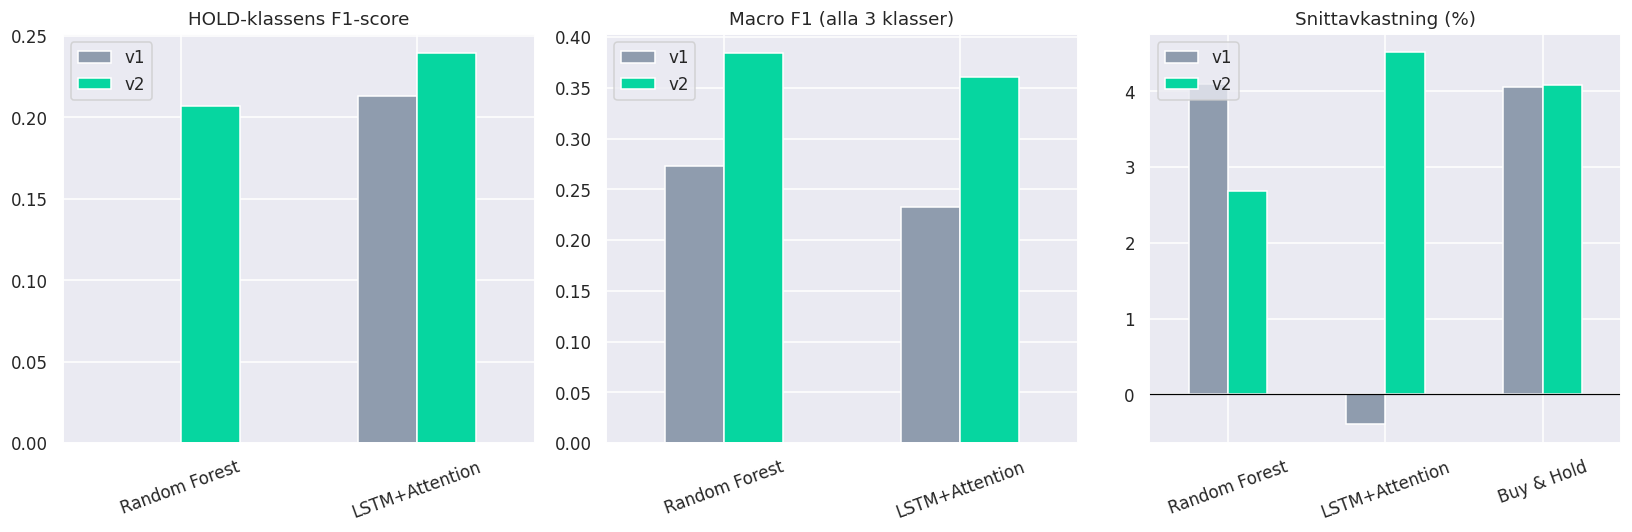

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

hold_f1 = pd.DataFrame({
    "v1": [report_v1["random_forest"]["classification"]["HOLD"]["f1-score"],
           report_v1["lstm"]["classification"]["HOLD"]["f1-score"]],
    "v2": [report["random_forest"]["classification"]["HOLD"]["f1-score"],
           report["lstm"]["classification"]["HOLD"]["f1-score"]],
}, index=["Random Forest", "LSTM+Attention"])
hold_f1.plot(kind="bar", ax=axes[0], color=["#8f9cae", "#06d6a0"])
axes[0].set_title("HOLD-klassens F1-score")
axes[0].tick_params(axis="x", rotation=20)

macro_f1 = pd.DataFrame({
    "v1": [report_v1["random_forest"]["classification"]["macro avg"]["f1-score"],
           report_v1["lstm"]["classification"]["macro avg"]["f1-score"]],
    "v2": [report["random_forest"]["classification"]["macro avg"]["f1-score"],
           report["lstm"]["classification"]["macro avg"]["f1-score"]],
}, index=["Random Forest", "LSTM+Attention"])
macro_f1.plot(kind="bar", ax=axes[1], color=["#8f9cae", "#06d6a0"])
axes[1].set_title("Macro F1 (alla 3 klasser)")
axes[1].tick_params(axis="x", rotation=20)

returns = pd.DataFrame({
    "v1": [report_v1["random_forest"]["avg_return"], report_v1["lstm"]["avg_return"], report_v1["buy_and_hold_avg_return"]],
    "v2": [report["random_forest"]["avg_return"], report["lstm"]["avg_return"], report["buy_and_hold_avg_return"]],
}, index=["Random Forest", "LSTM+Attention", "Buy & Hold"])
returns.plot(kind="bar", ax=axes[2], color=["#8f9cae", "#06d6a0"])
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Snittavkastning (%)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

> ✅ **Resultat** — den riktade förbättringen fungerade på det den var avsedd för: HOLD-klassen gick
> från fullständig kollaps (F1 = 0) till faktiskt mätbar signal för båda modellerna, och macro F1 steg
> tydligt för både RF och LSTM — modellerna särskiljer nu alla tre klasser istället för att bara gissa
> den vanligaste.
>
> 🚧 **Men, ärligt:** en bättre balanserad klassificerare är inte automatiskt en bättre handlare.
> LSTM+Attention gick från att förlora mot Buy & Hold till att slå det, men Random Forests
> backtest-avkastning sjönk och hamnade *under* Buy & Hold trots bättre klassificeringsmetrik — RF:s
> UP-recall (tidigare dess huvudsakliga styrka) sjönk kraftigt när modellen slutade "gissa UP" som
> standard. Det är en genuin, intressant lärdom snarare än ett problem att dölja: klassificeringskvalitet
> och finansiellt utfall är inte samma sak, och en fullständig lösning hade krävt att optimera
> handelsstrategin (t.ex. tröskelvärden för när en signal faktiskt ska trigga en affär) separat från
> klassificeringsmodellen. Vi har medvetet stannat här — se den metodiska gränsen ovan — men det är en
> tydlig kandidat för nästa iteration.

---
## 📝 Sammanfattning: beslut, hinder och nästa steg

**Beslutslogg (kronologisk, grundad i faktiska filtidsstämplar i repot):**

1. Projektet skaffoldades med central `config.py`, `src/`, `data/` och `notebooks/` (10 juni).
2. Kärnmodulerna `ingestion.py`, `features.py` och `models.py` skrevs samma dag — pipeline-designen
   (SQLite → FeatureEngine → RF/LSTM) låg fast från start.
3. En fristående, mindre EDA-övning (utanför huvudpipelinen, i `outputs/aapl_*`) gjordes som ett
   snabbt sanity-test av rensning/visualisering innan den fasta `src/eda.py`-modulen byggdes för
   samtliga OMXS30-tickers.
4. `preprocessing.py` och den automatiserade `eda.py` färdigställdes, följt av `evaluate.py` och
   dashboarden — och till sist genererades den riktiga utvärderingsrapporten (`evaluation_report.json`).
5. `notebooks/eda_analysis.ipynb` (en mer teknisk, cell-för-cell-genomgång av pipelinen) och denna
   berättande notebook skrevs som en sammanfattande genomgång inför inlämning.
6. En andra, avgränsad tränings-iteration (v1 → v2, Milstolpe 8) åtgärdade den asymmetriska
   etikett-definitionen, HOLD-klassens kollaps och det icke-deterministiska split-datumet — med
   v1 sparad som frusen baseline för en ärlig före/efter-jämförelse.

**Kända hinder, medvetet inte drivna längre:**
- Random Forests backtest-avkastning hamnade under Buy & Hold i v2, trots bättre klassificeringsmetrik
  — klassificeringskvalitet och finansiellt utfall visade sig inte vara samma sak (se Milstolpe 8).
  Nästa steg vore att optimera handelsstrategins tröskelvärden separat från klassificeraren.
- Olika historiklängd per ticker (t.ex. `ESSITY-B.ST`) hanteras men begränsar hur långt tillbaka en
  gemensam analys kan sträcka sig.
- HOLD-klassen är fortfarande den svagaste av de tre (F1 ≈ 0.2), bara inte längre obefintlig.

**Redan åtgärdat:**
- De tre parallella config-modulerna (root, `src/config.py`, `utils.py`) städades upp till en enda
  `config.py` i projektroten som samtliga moduler nu importerar från.
- Split-datumet är låst till senaste datumet i databasen istället för `pd.Timestamp.now()` —
  körningar är nu reproducerbara mellan varandra så länge databasen inte ändras.
- HOLD-klassens kollaps och den asymmetriska etikett-snedvridningen (Milstolpe 8).

Vi stannade medvetet vid v2 (se den metodiska gränsen i Milstolpe 8) istället för att fortsätta
justera mot samma testfönster. `plans/next_steps.md` listar ytterligare idéer om projektet drivs
vidare i en tredje iteration.